# 12 &middot; Quadratic (P2) finite elements

Every element so far has been **linear (P1)**: positions vary linearly inside a triangle, so the
deformation gradient $F$ is constant per element. **Quadratic (P2)** elements add a node at every
edge midpoint, so positions vary quadratically, $F$ varies *within* each element, and bending is
captured far more accurately on the same mesh. We plot both bases, sag a coarse cantilever with each,
show why P2 is not just a subdivided mesh, and measure convergence rates with a manufactured solution.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igl
import simkit
import utils

NOTEBOOK = "012_p2_finite_elements"                               # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)   # results/012_p2_finite_elements/
MEDIA_DIR = "media"                                               # tracked copies for the website
# Part A: basis functions
BASIS_SUBDIVS = 5                      # upsampling levels of the reference triangle (4^k samples)
# Part B: cantilever beam, left edge pinned, sagging under gravity
BEAM_NX, BEAM_NY = 5, 4                # grid vertices (deliberately coarse)
BEAM_WIDTH, BEAM_HEIGHT = 2.0, 0.3     # beam size
MATERIAL = "macklin-mueller-neo-hookean"
YM, PR = 300.0, 0.4                    # Young's modulus, Poisson ratio
RHO = 1.0                              # density
GRAVITY = -9.8                         # vertical acceleration
K_PIN = 1e7                            # soft-pin stiffness
QUAD_ORDER = 2                         # P2 cubature order for the elastic energy
DT = 0.01                              # backward-Euler timestep
T_TOTAL = 1.2                          # simulated time
N_FRAMES = 48                          # frames sampled for the animation
FPS = 24                               # animation frame rate
STATIC_FPS = 2                         # frame rate of the rest -> equilibrium clip
STEP_ITERS, STEP_TOL = 30, 1e-8        # Newton iterations / tolerance per timestep
STATIC_ITERS, STATIC_TOL = 200, 1e-9   # Newton iterations / tolerance for static equilibrium
FD_STEP = 1e-6                         # central-difference step for the gradient check
FD_NOISE = 0.05                        # random perturbation of the check state
SEED = 0                               # random seed for the gradient check
EDGE_SAMPLES = 12                      # samples per curved P2 edge when drawing
# Subdivision demo
BEND = 0.5                             # bending field phi(x, y) = (x, y + BEND x^2)
# Part C: manufactured-solution convergence (linear elasticity on the unit square)
MMS_YM, MMS_PR = 1.0, 0.3              # Young's modulus, Poisson ratio
MMS_RESOLUTIONS = [4, 8, 16, 32]       # elements per side of the unit square
MMS_QUAD_ORDER = 4                     # quadrature order for the load and error integrals
MMS_K_PIN = 1e10                       # boundary pin stiffness (u = 0)
MMS_SHOW_RES = 8                       # resolution whose pointwise error field is plotted
# plotting
COLORS = {"P1": "#d62728", "P2": "#1f77b4"}

## Part A &mdash; The basis functions

On the reference triangle the **P1** hats are the barycentric coordinates $L_i$ (planar ramps). The
**P2** corner functions $N_i = L_i(2L_i - 1)$ curve and dip slightly negative (down to $-\tfrac18$) in the band
between the dashed line $L_i = \tfrac12$ and the opposite edge, and the midpoint functions $N = 4L_aL_b$
are bumps centred on their edge.
`simkit.p2_shape_functions` evaluates them; each panel is a scalar field on an upsampled reference triangle.

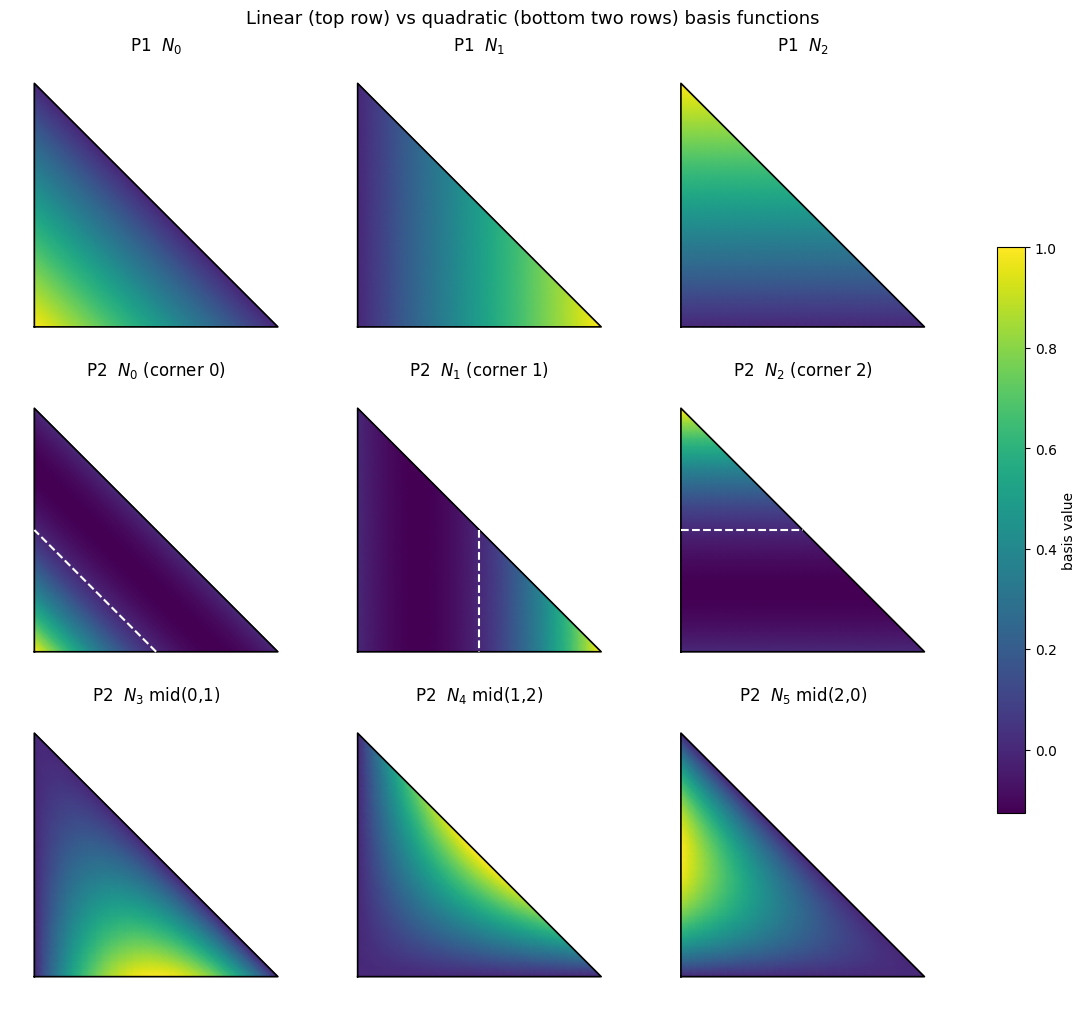

In [2]:
ref_V, ref_T = igl.upsample(np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]), np.array([[0, 1, 2]]), BASIS_SUBDIVS)
L = np.column_stack([1.0 - ref_V.sum(axis=1), ref_V])                # barycentric coordinates of every sample
P1_basis = L                                                          # (npts, 3)
P2_basis = np.array([simkit.p2_shape_functions(Li, 3)[0] for Li in L])  # (npts, 6), corners then midpoints

titles = [r"P1  $N_0$", r"P1  $N_1$", r"P1  $N_2$",
          r"P2  $N_0$ (corner 0)", r"P2  $N_1$ (corner 1)", r"P2  $N_2$ (corner 2)",
          r"P2  $N_3$ mid(0,1)", r"P2  $N_4$ mid(1,2)", r"P2  $N_5$ mid(2,0)"]
fields = [P1_basis[:, j] for j in range(3)] + [P2_basis[:, k] for k in range(6)]
fig, axes = plt.subplots(3, 3, figsize=(11, 10), layout="constrained")
for k, (ax, vals, title) in enumerate(zip(axes.ravel(), fields, titles)):
    m = utils.plot_scalar_field(ax, ref_V, ref_T, vals, title=title, edges=False, colorbar=False,
                                vmin=-0.125, vmax=1.0)
    ax.plot([0, 1, 0, 0], [0, 0, 1, 0], "k", lw=1.2)                  # reference-triangle outline
    if 3 <= k < 6:                                                    # P2 corner N_i < 0 where L_i < 1/2
        ax.tricontour(ref_V[:, 0], ref_V[:, 1], ref_T, L[:, k - 3], levels=[0.5], colors="w", linestyles="--")
    ax.axis("off")
fig.colorbar(m, ax=axes, shrink=0.6, label="basis value")
fig.suptitle("Linear (top row) vs quadratic (bottom two rows) basis functions", fontsize=13)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "p2_basis.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_p2_basis.png"))
plt.show()

## Part B &mdash; A beam sagging under gravity: P1 vs P2

Both element sets live on the same coarse grid. `linear_to_quadratic_elements` keeps the P1 corners
and appends one node per unique edge at its midpoint ($T_2$ is $t \times 6$), and
`gauss_legendre_quadrature` places symmetric cubature points (barycentric coordinates plus physical
weights) inside every element. The figure shows the P1 mesh, and the P2 mesh with its midpoint nodes
and cubature points; blue squares are the pinned left edge.

P1: 20 nodes, 24 elements, 40 dofs
P2: 63 nodes, 24 elements, 126 dofs, 3 cubature points per element


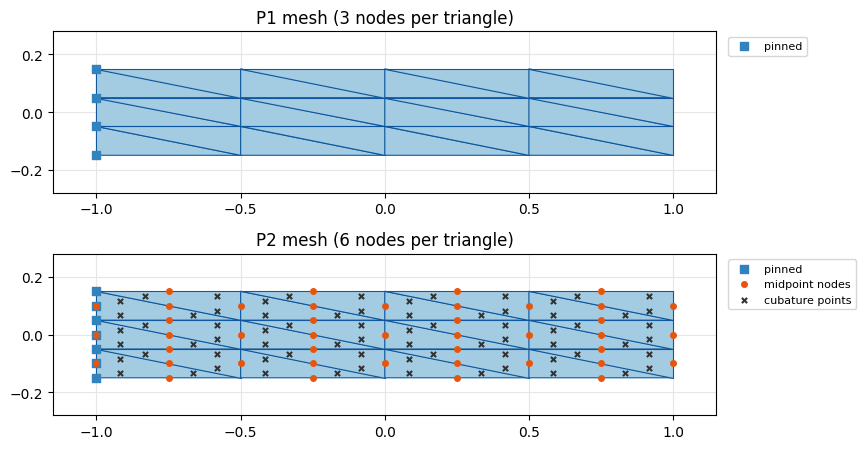

In [3]:
V, T = igl.triangulated_grid(BEAM_NX, BEAM_NY)                       # unit square grid
X = (V - 0.5) * np.array([BEAM_WIDTH, BEAM_HEIGHT])                  # centred beam
V2, T2 = simkit.linear_to_quadratic_elements(X, T)                   # corners first, then edge midpoints
bary, w = simkit.gauss_legendre_quadrature(X, T, QUAD_ORDER)         # (t, n_quad, 3), (t, n_quad)
pin1 = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
pin2 = np.where(V2[:, 0] <= V2[:, 0].min() + 1e-6)[0]
cub_rest = np.einsum("tqc,tcd->tqd", bary, X[T]).reshape(-1, 2)      # cubature points in the rest shape
n1, n2 = len(X), len(V2)
print(f"P1: {n1} nodes, {len(T)} elements, {2 * n1} dofs")
print(f"P2: {n2} nodes, {len(T2)} elements, {2 * n2} dofs, {bary.shape[1]} cubature points per element")

fig, axes = plt.subplots(2, 1, figsize=(9, 4.6))
lims = ((-1.15, 1.15), (-0.28, 0.28))
utils.plot_mesh(axes[0], X, T, pins=pin1, lims=lims, title="P1 mesh (3 nodes per triangle)")
utils.plot_mesh(axes[1], V2, T2[:, :3], pins=pin2, lims=lims, title="P2 mesh (6 nodes per triangle)")
axes[1].scatter(V2[n1:, 0], V2[n1:, 1], s=16, color=utils.HANDLE_C, zorder=4, label="midpoint nodes")
axes[1].scatter(cub_rest[:, 0], cub_rest[:, 1], s=14, marker="x", color="0.2", zorder=4, label="cubature points")
for ax in axes:
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "beam_meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_beam_meshes.png"))
plt.show()

### Two operator sets, one energy

With P1 the energy is a one-point rule per element; with P2 it becomes a sum over cubature points,

$$E_{P1} = \sum_t \text{vol}_t\, \psi(F_t), \qquad E_{P2} = \sum_t \sum_q w_{tq}\, \psi(F_{tq}).$$

so no energy code changes: each cubature point is a pseudo-element, and the weights `w` replace `vol`.
`deformation_jacobian_p2` is, like P1's, a **constant** sparse matrix built once from the rest geometry;
it just maps nodal positions to a *stack* of $F$ blocks, one per cubature point, because P2
shape-function gradients vary linearly inside the element. P2 also gets its own consistent mass matrix
and gravity force. The printout checks the shapes, and that weights and masses integrate the beam's area.

In [4]:
ops_p1 = dict(nodes=X, pins=pin1,
              J=simkit.deformation_jacobian(X, T),                                    # one F per element
              vol=simkit.volume(X, T),                                                # element areas
              M=sp.sparse.kron(simkit.massmatrix(X, T, rho=RHO), sp.sparse.eye(2)).tocsc(),
              f_g=simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1))
ops_p2 = dict(nodes=V2, pins=pin2,
              J=simkit.deformation_jacobian_p2(V2, T2, bary, w),                      # one F per cubature point
              vol=w.reshape(-1, 1),                                                   # cubature weights
              M=sp.sparse.kron(simkit.p2_massmatrix(V2, T2, bary, w, rho=RHO), sp.sparse.eye(2)).tocsc(),
              f_g=simkit.p2_gravity_force(V2, T2, bary, w, a=GRAVITY, rho=RHO).reshape(-1, 1))
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    print(f"{name}: J {ops['J'].shape} -> {ops['J'].shape[0] // 4} F blocks, "
          f"sum of weights = {ops['vol'].sum():.4f} (area {BEAM_WIDTH * BEAM_HEIGHT:.4f}), "
          f"total mass = {ops['M'].sum() / 2:.4f}")

P1: J (96, 40) -> 24 F blocks, sum of weights = 0.6000 (area 0.6000), total mass = 0.6000
P2: J (288, 126) -> 72 F blocks, sum of weights = 0.6000 (area 0.6000), total mass = 0.6000


### The beam system

`beam_system` builds a hyperelastic (`MATERIAL`) beam from whichever operators it is handed; it cannot tell P1 from P2.
Its terms are the elastic energy, the soft pin on the left edge, gravity, and, when the previous
positions `x_curr, x_prev` are passed, the backward-Euler inertia term (one implicit step). Without them
it is the static potential used for the equilibrium comparison later.

In [5]:
def beam_system(nodes, pins, J, vol, M, f_g, x_curr=None, x_prev=None):
    """Elastic + soft pin + gravity (+ backward-Euler inertia if x_curr, x_prev are given)."""
    n, dim = nodes.shape
    mu, lam = simkit.ympr_to_lame(YM, PR)
    mu = np.full((vol.shape[0], 1), mu)
    lam = np.full((vol.shape[0], 1), lam)
    Q_pin, b_pin = simkit.dirichlet_penalty(pins, nodes[pins], n, K_PIN)
    dynamic = x_curr is not None

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_gravity = -(f_g.T @ x).item()
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT) if dynamic else 0.0
        E_total = E_elastic + E_pin + E_gravity + E_inertia
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_gravity = -f_g
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT) if dynamic else 0.0
        g_total = g_elastic + g_pin + g_gravity + g_inertia
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_inertia = simkit.energies.kinetic_hessian_be(M, DT) if dynamic else 0.0
        H_total = H_elastic + H_pin + H_inertia
        return H_total

    return energy_func, gradient_func, hessian_func

Before simulating, we check `gradient_func` against a central-difference gradient of `energy_func`
(`simkit.gradient_cfd`) at a randomly perturbed state, for both element sets with inertia switched on.
Relative errors near $10^{-8}$ or below mean the analytic gradient is right.

In [6]:
rng = np.random.default_rng(SEED)
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    x_rest = ops["nodes"].reshape(-1, 1)
    energy_func, gradient_func, _ = beam_system(**ops, x_curr=x_rest, x_prev=x_rest)
    x_test = x_rest + FD_NOISE * rng.standard_normal(x_rest.shape)
    g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
    g = gradient_func(x_test).ravel()
    print(f"{name}: relative gradient error = {np.linalg.norm(g - g_fd) / np.linalg.norm(g):.2e}")

P1: relative gradient error = 8.25e-09
P2: relative gradient error = 1.66e-08


### Curved (true-geometry) rendering of P2 elements

A P2 edge between corners $a, b$ with midpoint node $m$ is a *parabola* in the edge parameter $t \in [0, 1]$:

$$x(t) = (1-t)(1-2t)\, U_a + t(2t-1)\, U_b + 4t(1-t)\, U_m .$$

`p2_curved_outline` samples these three parabolas for every element and returns the points plus one
polygon per element, so the ordinary mesh drawing helpers can show the real curved boundary, which no
straight-edged (P1) element can produce.

In [7]:
edge_t = np.linspace(0.0, 1.0, EDGE_SAMPLES)
edge_N = np.column_stack([(1 - edge_t) * (1 - 2 * edge_t), edge_t * (2 * edge_t - 1), 4 * edge_t * (1 - edge_t)])
P2_EDGES = [(0, 1, 3), (1, 2, 4), (2, 0, 5)]                          # (corner a, corner b, midpoint) per edge

def p2_curved_outline(U2, T2):
    """Sample every P2 element's parabolic edges: points (t*3*S, 2) and polygons (t, 3*S)."""
    loops = [np.vstack([edge_N @ U2[[el[a], el[b], el[m]]] for a, b, m in P2_EDGES]) for el in T2]
    points = np.vstack(loops)
    polygons = np.arange(len(points)).reshape(len(T2), -1)
    return points, polygons

### Running both beams

Each beam takes `T_TOTAL / DT` backward-Euler steps: rebuild `beam_system` with the current and previous
positions, then minimize it with Newton. We keep `N_FRAMES` evenly spaced frames and the height of the
lowest point at every step. In the animation P1 is drawn with its straight triangles and P2 with its
true curved edges: same mesh, material and timestep, yet only the P2 beam bends smoothly.

In [8]:
n_steps = int(round(T_TOTAL / DT))
frame_steps = set(np.round(np.linspace(0, n_steps, N_FRAMES)).astype(int))
frames, tip_y = {}, {}
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    x_curr = ops["nodes"].reshape(-1, 1).copy()
    x_prev = x_curr.copy()                                            # starts at rest
    frames[name], tip_y[name] = [ops["nodes"].copy()], [ops["nodes"][:, 1].min()]
    for step in range(1, n_steps + 1):
        energy_func, gradient_func, hessian_func = beam_system(**ops, x_curr=x_curr, x_prev=x_prev)
        x_next = simkit.solvers.newton_solver(x_curr.copy(), energy_func, gradient_func, hessian_func,
                                              max_iter=STEP_ITERS, tolerance=STEP_TOL)
        x_prev, x_curr = x_curr, x_next
        tip_y[name].append(x_curr.reshape(-1, 2)[:, 1].min())
        if step in frame_steps:
            frames[name].append(x_curr.reshape(-1, 2).copy())

_, curved_polys = p2_curved_outline(V2, T2)
curved_p2 = [p2_curved_outline(U, T2)[0] for U in frames["P2"]]
fig, anim = utils.animate_meshes_grid(
    [{"states": frames["P1"], "T": T, "title": "Linear (P1) - straight edges"},
     {"states": curved_p2, "T": curved_polys, "title": "Quadratic (P2) - true curved edges"}],
    lims=utils.auto_limits(frames["P1"] + curved_p2, pad=0.15), fps=FPS, figsize=(9.4, 4.6),
    suptitle="Same mesh, same material, same dt: only P2's edges can curve")
fig.tight_layout()
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "p1_vs_p2_beam.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "012_p1_vs_p2_beam.mp4"))
plt.close(fig)
utils.embed_video(video)

The height of the lowest point over time makes the comparison quantitative: the softer P2 beam falls
further and then rebounds (at the end it whips back up, as in the last frames above), while the stiff
P1 beam bottoms out higher and barely rebounds; the curves drift apart as the beams go out of phase.

P1: lowest point -1.862 at t = 0.82 s
P2: lowest point -2.034 at t = 0.79 s


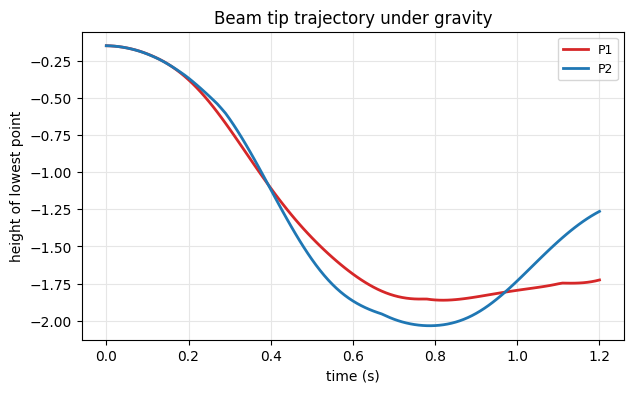

In [9]:
times = DT * np.arange(n_steps + 1)
fig, ax = utils.line_plot(times, {"P1": tip_y["P1"], "P2": tip_y["P2"]}, colors=COLORS,
                          xlabel="time (s)", ylabel="height of lowest point",
                          title="Beam tip trajectory under gravity", figsize=(7, 4))
for name in tip_y:
    print(f"{name}: lowest point {min(tip_y[name]):.3f} at t = {DT * np.argmin(tip_y[name]):.2f} s")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tip_trajectory.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_tip_trajectory.png"))
plt.show()

### Wait &mdash; is this just a subdivided mesh?

A P2 element and a triangle subdivided into 4 linear sub-triangles use the *same 6 nodes*; the
difference is the **function space** (table). Below, one triangle is deformed by the quadratic bending
field $\phi(x, y) = (x,\ y + \tfrac12 x^2)$ and drawn three ways: P1 stays flat, subdivision is a kinked
chord, and only the quadratic basis matches the true shape (dashed grey), which is why P2 reproduces
quadratic fields exactly while no linear scheme on these nodes can.

| scheme | nodes | within an element | edges |
|---|---|---|---|
| **P1 linear** | 3 corners | constant $F$ | straight |
| **Subdivided P1** | same 6 | piecewise-constant $F$, kinks at midpoints | straight chords |
| **P2 quadratic** | same 6 | $F$ varies linearly and smoothly | **curved (parabolic)** |

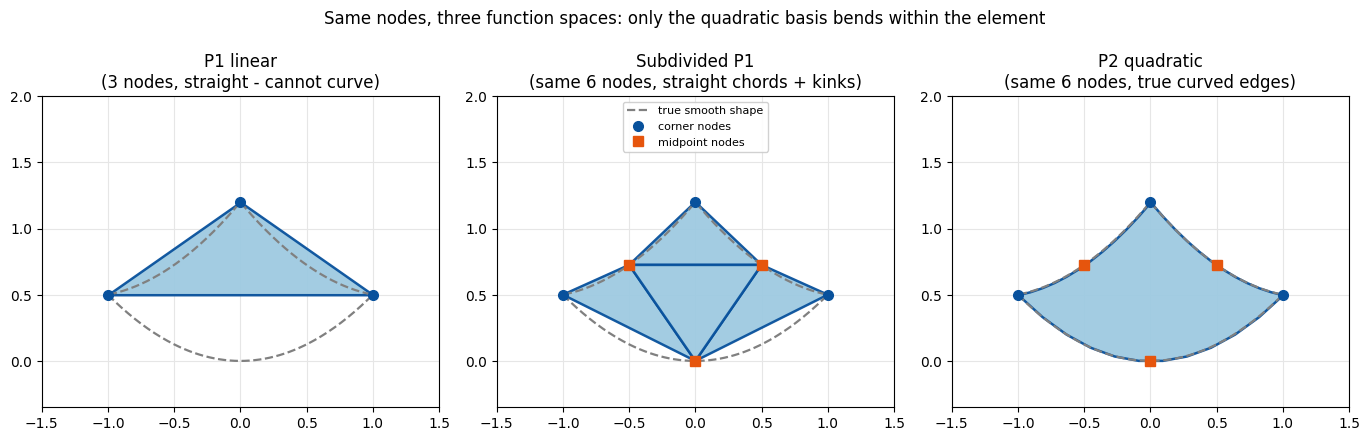

In [10]:
def phi(P):
    """Quadratic bending field phi(x, y) = (x, y + BEND x^2)."""
    P = np.atleast_2d(P)
    return np.column_stack([P[:, 0], P[:, 1] + BEND * P[:, 0] ** 2])

corners = np.array([[-1.0, 0.0], [1.0, 0.0], [0.0, 1.2]])
node6 = np.vstack([corners, 0.5 * (corners + np.roll(corners, -1, axis=0))])   # [c0, c1, c2, m01, m12, m20]
U6 = phi(node6)
s = np.linspace(0, 1, 160)[:, None]
truth = phi(np.vstack([(1 - s) * corners[i] + s * corners[(i + 1) % 3] for i in range(3)]))  # true outline
T_sub = np.array([[0, 3, 5], [3, 1, 4], [5, 4, 2], [3, 4, 5]])                 # 4-way subdivision
P_curved, poly_curved = p2_curved_outline(U6, np.array([[0, 1, 2, 3, 4, 5]]))
panels = [("P1 linear\n(3 nodes, straight - cannot curve)", U6[:3], np.array([[0, 1, 2]])),
          ("Subdivided P1\n(same 6 nodes, straight chords + kinks)", U6, T_sub),
          ("P2 quadratic\n(same 6 nodes, true curved edges)", P_curved, poly_curved)]

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.7))
for ax, (title, P, F) in zip(axes, panels):
    utils.plot_mesh(ax, P, F, lims=((-1.5, 1.5), (-0.35, 2.0)), title=title, lw=1.8)
    ax.plot(np.r_[truth[:, 0], truth[0, 0]], np.r_[truth[:, 1], truth[0, 1]],
            color="0.5", lw=1.6, ls="--", zorder=4, label="true smooth shape")
    ax.plot(U6[:3, 0], U6[:3, 1], "o", color=utils.MESH_EDGE, ms=7, zorder=5, label="corner nodes")
    if ax is not axes[0]:
        ax.plot(U6[3:, 0], U6[3:, 1], "s", color=utils.HANDLE_C, ms=7, zorder=5, label="midpoint nodes")
axes[1].legend(loc="upper center", fontsize=8, framealpha=0.9)
fig.suptitle("Same nodes, three function spaces: only the quadratic basis bends within the element", fontsize=12)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "p1_vs_subdivided_vs_p2.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_p1_vs_subdivided_vs_p2.png"))
plt.show()

### Static equilibrium: the unambiguous stiffness comparison

The animation includes inertia, so at any instant both beams are still swinging (slightly out of phase,
since their mass distributions differ). To compare *stiffness* cleanly we build `beam_system` without
the inertia term and solve for the gravity equilibrium each beam eventually settles into. The clip
alternates between rest and equilibrium; linear triangles cannot bend within an element, so P1 is
artificially **stiff** and deflects less.

In [11]:
eq, newton_grad = {}, {}
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    energy_func, gradient_func, hessian_func = beam_system(**ops)                # static: no inertia
    x_eq, info = simkit.solvers.newton_solver(ops["nodes"].reshape(-1, 1).copy(), energy_func, gradient_func,
                                              hessian_func, max_iter=STATIC_ITERS, tolerance=STATIC_TOL,
                                              return_info=True)
    eq[name] = x_eq.reshape(-1, 2)
    newton_grad[name] = [np.linalg.norm(g) for g in info["g"]] + [np.linalg.norm(gradient_func(x_eq))]
tip = {name: eq[name][:, 1].min() for name in eq}
print(f"P1 tip deflection: {tip['P1']:.4f}")
print(f"P2 tip deflection: {tip['P2']:.4f}   (P2 is {100 * (tip['P2'] - tip['P1']) / tip['P1']:.1f}% more compliant)")

curved_static = [p2_curved_outline(U, T2)[0] for U in (V2, eq["P2"])]
fig, anim = utils.animate_meshes_grid(
    [{"states": [X, eq["P1"]], "T": T, "title": f"P1 equilibrium (tip {tip['P1']:.3f})"},
     {"states": curved_static, "T": curved_polys, "title": f"P2 equilibrium (tip {tip['P2']:.3f}, curved)"}],
    lims=utils.auto_limits([X, eq["P1"]] + curved_static, pad=0.15), fps=STATIC_FPS, figsize=(9.4, 4.6),
    suptitle="Static gravity equilibrium: linear elements are stiffer (deflect less)")
fig.tight_layout()
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "p1_vs_p2_static.mp4"), fps=STATIC_FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "012_p1_vs_p2_static.mp4"))
plt.close(fig)
utils.embed_video(video)

P1 tip deflection: -1.4120
P2 tip deflection: -1.8620   (P2 is 31.9% more compliant)


As a solver check, the gradient norm per Newton iteration of both static solves. After the line-searched
large-deformation phase it falls by roughly 5 (P2) to 7 (P1) orders of magnitude from its peak, until the
Newton step is below `STATIC_TOL`. The tail is linear rather than quadratic because `psd=True` projects
each element Hessian to be positive semi-definite, which only approximates the true Hessian where
elements are compressed.

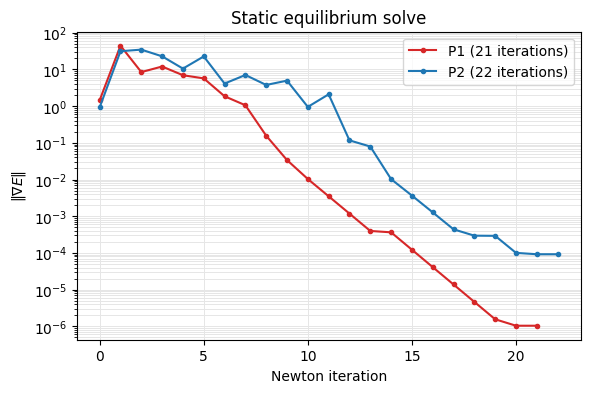

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for name, gnorm in newton_grad.items():
    ax.semilogy(gnorm, "-o", ms=3, color=COLORS[name], label=f"{name} ({len(gnorm) - 1} iterations)")
ax.set_xlabel("Newton iteration")
ax.set_ylabel(r"$\|\nabla E\|$")
ax.set_title("Static equilibrium solve")
ax.grid(True, which="both", color="0.9", linewidth=0.7)
ax.legend()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "static_newton.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_static_newton.png"))
plt.show()

The elastic energy density $\psi(F)$ at equilibrium shows *why* P1 is stiff. P1 has one $F$, hence one
$\psi$, per triangle (flat colours); P2 has one per cubature point (dots at their deformed positions), so
the strain varies inside each element and the curvature is carried smoothly instead of being forced
into piecewise-constant pieces. Both panels share one logarithmic colour scale.

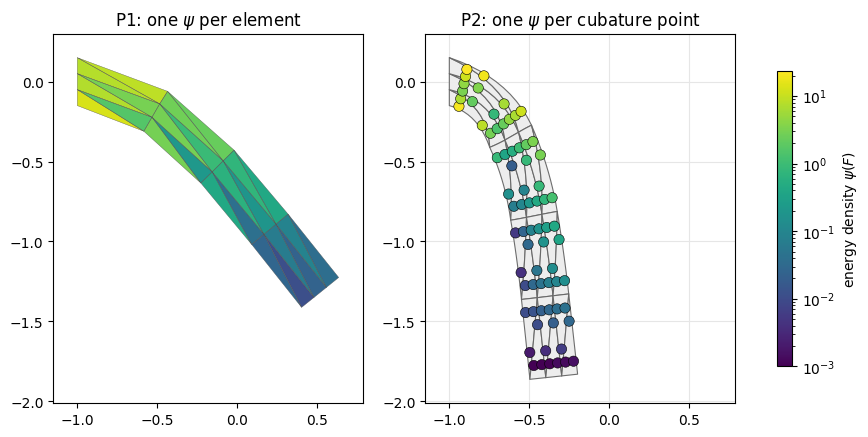

In [13]:
mu, lam = simkit.ympr_to_lame(YM, PR)
psi = {}
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    F = (ops["J"] @ eq[name].reshape(-1, 1)).reshape(-1, 2, 2)                     # one F per block
    n_blocks = len(F)
    psi[name] = simkit.energies.elastic_energy_element_F(F, np.full((n_blocks, 1), mu),
                                                         np.full((n_blocks, 1), lam), MATERIAL).ravel()
N_quad = np.array([simkit.p2_shape_functions(Lq, 3)[0] for Lq in bary[0]])          # (n_quad, 6), same rule per element
cub_eq = np.einsum("qi,tid->tqd", N_quad, eq["P2"][T2]).reshape(-1, 2)              # deformed cubature points
norm = LogNorm(vmin=1e-3, vmax=max(psi["P1"].max(), psi["P2"].max()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
lims = utils.auto_limits([eq["P1"], eq["P2"]], pad=0.15)
utils.plot_scalar_field(axes[0], eq["P1"], T, np.maximum(psi["P1"], norm.vmin), lims=lims, norm=norm,
                        title="P1: one $\\psi$ per element", colorbar=False)
utils.plot_mesh(axes[1], p2_curved_outline(eq["P2"], T2)[0], curved_polys, lims=lims,
                facecolor="0.93", edgecolor="0.4", title="P2: one $\\psi$ per cubature point")
m = axes[1].scatter(cub_eq[:, 0], cub_eq[:, 1], c=np.maximum(psi["P2"], norm.vmin), s=55, norm=norm,
                    edgecolors="k", linewidths=0.4, zorder=6)
fig.colorbar(m, ax=axes, shrink=0.8, label=r"energy density $\psi(F)$")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy_density.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_energy_density.png"))
plt.show()

## Part C &mdash; Convergence: P1 is first order, P2 is second order

The real payoff of quadratic elements is **accuracy per refinement**. With the *method of manufactured
solutions* we pick the exact displacement $u^*(x,y) = (s, s)$, $s = \sin(\pi a)\sin(\pi b)$,
$a = x + \tfrac12$, $b = y + \tfrac12$ on the unit square (zero on the boundary), and derive the body
force $b = -\operatorname{div}\sigma(u^*) = -\mu\Delta u^* - (\mu + \lambda)\nabla(\nabla\cdot u^*)$
that makes it the solution of **linear elasticity** (a linear PDE, so the rates are textbook-clean).
Below: the exact field $s$ and the body force component $b_x$ on the finest mesh.

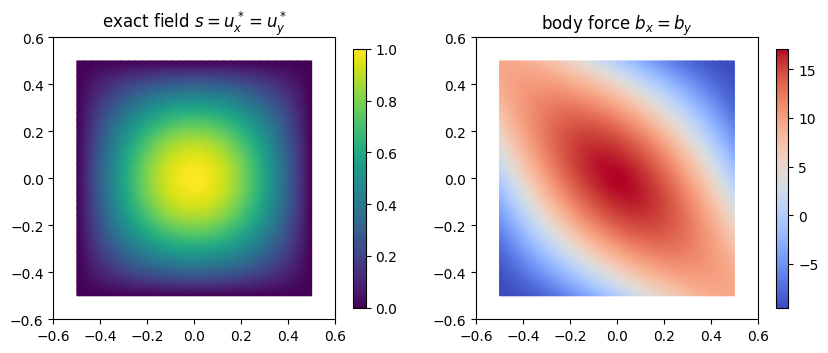

In [14]:
mms_mu, mms_lam = simkit.ympr_to_lame(MMS_YM, MMS_PR)

def u_star(P):
    """Exact displacement (s, s); zero on the boundary."""
    a, b = P[..., 0] + 0.5, P[..., 1] + 0.5
    s = np.sin(np.pi * a) * np.sin(np.pi * b)
    return np.stack([s, s], axis=-1)

def grad_u_star(P):
    """Exact displacement gradient at one point: rows = component i, cols = d/dX_j."""
    a, b = P[0] + 0.5, P[1] + 0.5
    sx = np.pi * np.cos(np.pi * a) * np.sin(np.pi * b)
    sy = np.pi * np.sin(np.pi * a) * np.cos(np.pi * b)
    return np.array([[sx, sy], [sx, sy]])

def body_force(P):
    """b = -mu Lap(u*) - (mu + lam) grad(div u*), at one point."""
    a, b = P[0] + 0.5, P[1] + 0.5
    s = np.sin(np.pi * a) * np.sin(np.pi * b)
    c = np.cos(np.pi * a) * np.cos(np.pi * b)
    b_shear = 2 * mms_mu * np.pi ** 2 * s                                # -mu Lap(u*)
    b_volumetric = -(mms_mu + mms_lam) * np.pi ** 2 * (c - s)            # -(mu + lam) grad(div u*)
    b_total = b_shear + b_volumetric
    return np.array([b_total, b_total])

mms_meshes = {}
for nn in MMS_RESOLUTIONS:
    V_unit, T_mms = igl.triangulated_grid(nn + 1, nn + 1)
    mms_meshes[nn] = (V_unit - 0.5, T_mms)                                   # unit square [-1/2, 1/2]^2
X_fine, T_fine = mms_meshes[MMS_RESOLUTIONS[-1]]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
utils.plot_scalar_field(axes[0], X_fine, T_fine, u_star(X_fine)[:, 0], edges=False, title="exact field $s = u^*_x = u^*_y$")
utils.plot_scalar_field(axes[1], X_fine, T_fine, [body_force(p)[0] for p in X_fine], edges=False,
                        cmap="coolwarm", title="body force $b_x = b_y$")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mms_solution.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_mms_solution.png"))
plt.show()

The finite-element pieces, identical for P1 and P2 apart from the shape functions:

- `assemble_load`: the consistent load $f_i = \int N_i\, b \, dV$ by quadrature.
- `mms_system`: linear elasticity + a stiff $u = 0$ boundary pin + the load potential $-f^\top x$. It is
  quadratic, so a single undamped Newton step from rest is the exact solve.
- `error_norms`: the **L2** displacement error $\lVert u_h - u^*\rVert$ and the **H1** (strain) seminorm
  error $\lVert \nabla u_h - \nabla u^*\rVert$, integrated by quadrature (with $\nabla u_h = F - I$).

In [15]:
def assemble_load(nodes, T_el, bary, weights, shape_at):
    """Consistent load vector f_i = integral N_i b dV, by quadrature."""
    f = np.zeros(nodes.shape)
    for e in range(len(T_el)):
        X_corners = nodes[T_el[e, :3]]                                   # corners -> affine rest map
        for q in range(bary.shape[1]):
            L_q = bary[e, q]
            N = shape_at(L_q)
            b_q = body_force(L_q @ X_corners)
            for i, node in enumerate(T_el[e]):
                f[node] += weights[e, q] * N[i] * b_q
    return f

def mms_system(nodes, J, vol, f_load, bnd):
    """Linear elasticity + stiff boundary pin (u = 0) + body-force load, in stacked positions x."""
    n, dim = nodes.shape
    mu = np.full((vol.shape[0], 1), mms_mu)
    lam = np.full((vol.shape[0], 1), mms_lam)
    Q_pin, b_pin = simkit.dirichlet_penalty(bnd, nodes[bnd], n, MMS_K_PIN)
    f = f_load.reshape(-1, 1)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, "linear-elasticity")
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_load = -(f.T @ x).item()
        E_total = E_elastic + E_pin + E_load
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, "linear-elasticity")
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_load = -f
        g_total = g_elastic + g_pin + g_load
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, "linear-elasticity")
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_elastic + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

def error_norms(nodes, T_el, x, bary, weights, F, shape_at):
    """L2 displacement error and H1 (strain) seminorm error against the exact field."""
    l2_sq, h1_sq = 0.0, 0.0
    for e in range(len(T_el)):
        X_corners = nodes[T_el[e, :3]]
        u_el = x[T_el[e]] - nodes[T_el[e]]                               # nodal displacements
        for q in range(bary.shape[1]):
            x_q = bary[e, q] @ X_corners
            u_h = shape_at(bary[e, q]) @ u_el                            # interpolated FE displacement
            l2_sq += weights[e, q] * np.sum((u_h - u_star(x_q)) ** 2)
            h1_sq += weights[e, q] * np.sum((F[e, q] - np.eye(2) - grad_u_star(x_q)) ** 2)
    return np.sqrt(l2_sq), np.sqrt(h1_sq)

P1_SHAPE = lambda L: L                                                   # linear hats = barycentric coordinates
P2_SHAPE = lambda L: simkit.p2_shape_functions(L, 3)[0]                  # quadratic shape functions

The refinement sequence. Every boundary node (blue) is pinned to $u = 0$; P2 uses the same meshes plus
their edge midpoints.

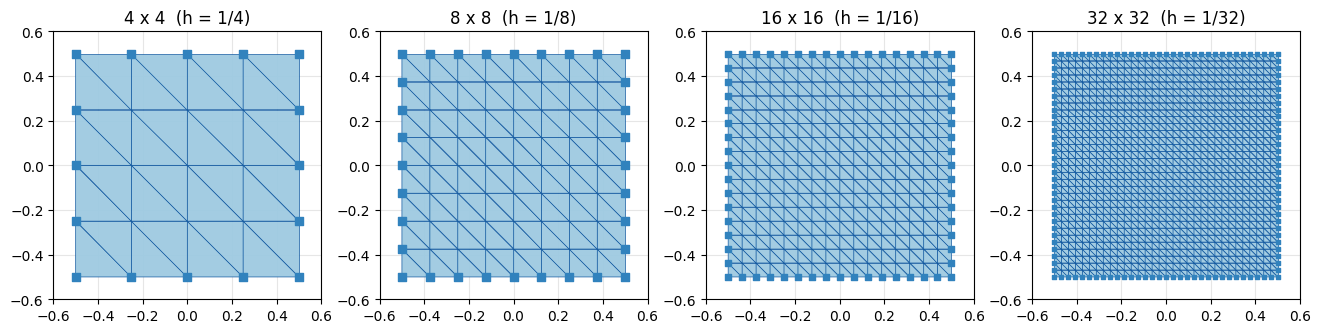

In [16]:
fig, axes = plt.subplots(1, len(MMS_RESOLUTIONS), figsize=(3.3 * len(MMS_RESOLUTIONS), 3.4))
for ax, (nn, (Xm, Tm)) in zip(axes, mms_meshes.items()):
    bnd = np.where(np.abs(Xm).max(axis=1) > 0.5 - 1e-9)[0]
    utils.plot_mesh(ax, Xm, Tm, lw=0.5, title=f"{nn} x {nn}  (h = 1/{nn})")
    ax.scatter(Xm[bnd, 0], Xm[bnd, 1], s=min(28, 240 / nn), marker="s", color=utils.PIN_C, zorder=4)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mms_meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_mms_meshes.png"))
plt.show()

### Refinement sweep

On each mesh we solve the manufactured problem with P1 and with P2 (order-2 cubature for the stiffness,
order `MMS_QUAD_ORDER` for load and errors) and record both error norms. The printed orders are the
slopes of $\log(\text{error})$ against $\log h$.

In [17]:
hs = np.array([1.0 / nn for nn in MMS_RESOLUTIONS])
err = {"P1 L2": [], "P1 H1": [], "P2 L2": [], "P2 H1": []}
solutions = {}
for nn in MMS_RESOLUTIONS:
    Xm, Tm = mms_meshes[nn]
    bq, wq = simkit.gauss_legendre_quadrature(Xm, Tm, MMS_QUAD_ORDER)   # accurate load + error quadrature

    # --- P1 ---
    J1, vol1 = simkit.deformation_jacobian(Xm, Tm), simkit.volume(Xm, Tm)
    f1 = assemble_load(Xm, Tm, bq, wq, P1_SHAPE)
    bnd1 = np.where(np.abs(Xm).max(axis=1) > 0.5 - 1e-9)[0]
    energy_func, gradient_func, hessian_func = mms_system(Xm, J1, vol1, f1, bnd1)
    x1 = simkit.solvers.newton_solver(Xm.reshape(-1, 1).copy(), energy_func, gradient_func, hessian_func,
                                      max_iter=1, do_line_search=False).reshape(-1, 2)
    F1 = np.repeat(simkit.deformation_gradient(Xm, Tm, x1)[:, None], bq.shape[1], axis=1)
    l2, h1 = error_norms(Xm, Tm, x1, bq, wq, F1, P1_SHAPE)
    err["P1 L2"].append(l2)
    err["P1 H1"].append(h1)

    # --- P2 ---
    Vm2, Tm2 = simkit.linear_to_quadratic_elements(Xm, Tm)
    b2, w2 = simkit.gauss_legendre_quadrature(Xm, Tm, QUAD_ORDER)       # stiffness cubature
    J2, vol2 = simkit.deformation_jacobian_p2(Vm2, Tm2, b2, w2), w2.reshape(-1, 1)
    f2 = assemble_load(Vm2, Tm2, bq, wq, P2_SHAPE)
    bnd2 = np.where(np.abs(Vm2).max(axis=1) > 0.5 - 1e-9)[0]
    energy_func, gradient_func, hessian_func = mms_system(Vm2, J2, vol2, f2, bnd2)
    x2 = simkit.solvers.newton_solver(Vm2.reshape(-1, 1).copy(), energy_func, gradient_func, hessian_func,
                                      max_iter=1, do_line_search=False).reshape(-1, 2)
    F2 = simkit.deformation_gradient_p2(Vm2, Tm2, bq, x2)
    l2, h1 = error_norms(Vm2, Tm2, x2, bq, wq, F2, P2_SHAPE)
    err["P2 L2"].append(l2)
    err["P2 H1"].append(h1)
    solutions[nn] = (x1, x2)

slope = lambda e: np.polyfit(np.log(hs), np.log(e), 1)[0]
print(f"P1  H1 (strain) order = {slope(err['P1 H1']):.2f}   (theory 1)")
print(f"P2  H1 (strain) order = {slope(err['P2 H1']):.2f}   (theory 2)")
print(f"P1  L2 (displ.) order = {slope(err['P1 L2']):.2f}   (theory 2)")
print(f"P2  L2 (displ.) order = {slope(err['P2 L2']):.2f}   (theory 3)")

P1  H1 (strain) order = 0.99   (theory 1)
P2  H1 (strain) order = 1.99   (theory 2)
P1  L2 (displ.) order = 1.90   (theory 2)
P2  L2 (displ.) order = 3.07   (theory 3)


The pointwise displacement error $|u_h - u^*|$ at the corner nodes of the `MMS_SHOW_RES` mesh (note the
separate colour scales): on the same mesh P2 is roughly two orders of magnitude more accurate.

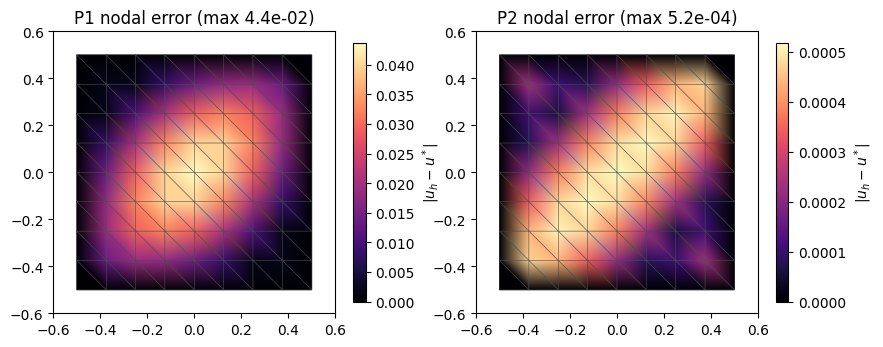

In [18]:
Xm, Tm = mms_meshes[MMS_SHOW_RES]
x1, x2 = solutions[MMS_SHOW_RES]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (name, x) in zip(axes, (("P1", x1), ("P2", x2[:len(Xm)]))):
    node_err = np.linalg.norm(x - Xm - u_star(Xm), axis=1)
    utils.plot_scalar_field(ax, Xm, Tm, node_err, cmap="magma",
                            title=f"{name} nodal error (max {node_err.max():.1e})", label="$|u_h - u^*|$")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mms_error_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_mms_error_fields.png"))
plt.show()

For a smooth solution and degree-$p$ elements, theory predicts these rates, and the log-log plot
confirms them (dashed guides). Halving $h$ cuts P1's strain error by ~2 but P2's by ~4, so P2 reaches a
target accuracy on a far coarser mesh.

| norm | rate | P1 ($p=1$) | P2 ($p=2$) |
|---|---|---|---|
| **H1 / strain** | $O(h^p)$ | $O(h)$ | $O(h^2)$ |
| **L2 / displacement** | $O(h^{p+1})$ | $O(h^2)$ | $O(h^3)$ |

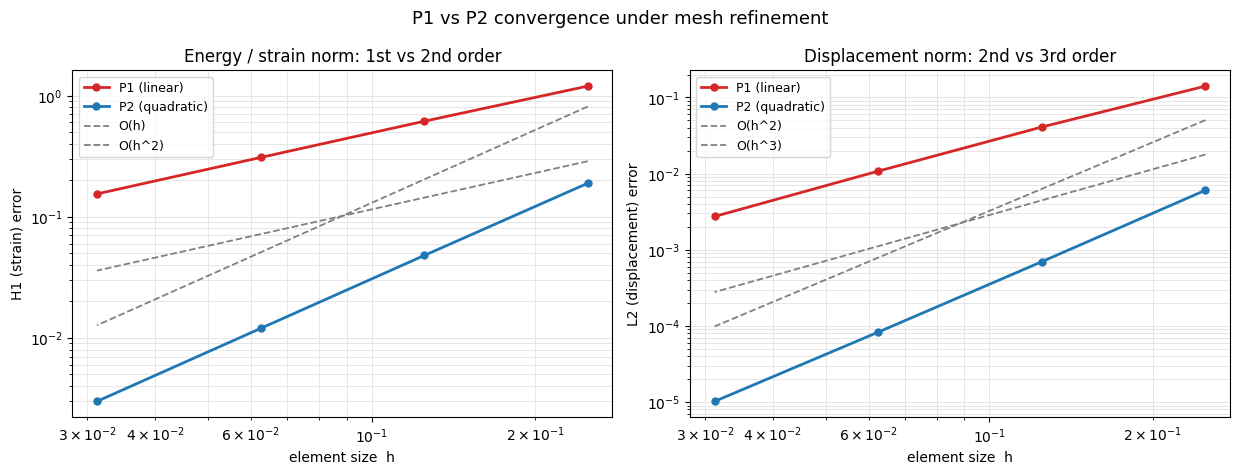

In [19]:
colors = {"P1 (linear)": COLORS["P1"], "P2 (quadratic)": COLORS["P2"]}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
utils.loglog_plot(hs, {"P1 (linear)": err["P1 H1"], "P2 (quadratic)": err["P2 H1"]},
                  xlabel="element size  h", ylabel="H1 (strain) error", colors=colors,
                  ref_slopes={"O(h)": 1, "O(h^2)": 2},
                  title="Energy / strain norm: 1st vs 2nd order", ax=axes[0])
utils.loglog_plot(hs, {"P1 (linear)": err["P1 L2"], "P2 (quadratic)": err["P2 L2"]},
                  xlabel="element size  h", ylabel="L2 (displacement) error", colors=colors,
                  ref_slopes={"O(h^2)": 2, "O(h^3)": 3},
                  title="Displacement norm: 2nd vs 3rd order", ax=axes[1])
fig.suptitle("P1 vs P2 convergence under mesh refinement", fontsize=13)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "012_convergence.png"))
plt.show()

### Takeaways

- At static equilibrium the **P1** beam is artificially **stiff** (it cannot bend within an element) and
  deflects less; **P2** sags further and more smoothly, with strain varying inside each element.
- **It is not a subdivided mesh**: both use the same 6 nodes, but only the quadratic basis has genuinely
  curved (parabolic) edges and reproduces quadratic fields exactly.
- **Convergence**: P1 is first order and P2 second order in the strain (H1) norm, one order higher each in
  L2, so P2 reaches a target accuracy on a much coarser mesh.
- The elastic energy, gradient and Hessian code is **unchanged**: P2 only swaps $J$ (one $F$ per
  cubature point), the integration weights, and the mass/gravity assembly.